<a href="https://www.kaggle.com/code/sonawanelalitsunil/average-salary-by-job-role-ml-22?scriptVersionId=232304152" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/average-salary-by-job-classification/Average_Salary_by_Job_Classification.csv


## Title: Average Salary by Job Role

#### Description: A comparison of average salaries across different job classifications to highlight income trends by role.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/average-salary-by-job-classification/Average_Salary_by_Job_Classification.csv')

In [3]:
df.head()

,Position Title,Position Class Code,Grade,Average of Base Salary,Number of Employees
0,Information Technology Expert,550,32,"$146,925.34",9
1,Accountant/Auditor II,210,21,"$82,742.44",2
2,Veterinary Assistant,206513,15,"$45,925.44",2
3,Police Aide,3506,15,"$58,628.63",15
4,ERP Functional Business Analyst,100546,30,"$133,797.25",3


In [4]:
df.tail()

,Position Title,Position Class Code,Grade,Average of Base Salary,Number of Employees
316,Correctional Supervisor - Sergeant,3234,C6,"$94,434.43",37
317,Police Captain,3063,A3,"$156,780.64",21
318,Deputy Sheriff III,3529,G4,"$83,677.86",66
319,Manager III,112,M3,"$132,146.03",252
320,Correctional Specialist IV,3247,25,"$105,117.90",4


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Position Title          321 non-null    object
 1   Position Class Code     321 non-null    int64 
 2   Grade                   321 non-null    object
 3   Average of Base Salary  321 non-null    object
 4   Number of Employees     321 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 12.7+ KB


In [6]:
df.describe()

,Position Class Code,Number of Employees
count,321.000000,321.000000
mean,20739.056075,23.242991
std,50417.952447,68.716561
min,110.000000,1.000000
25%,2013.000000,2.000000
50%,3523.000000,5.000000
75%,5190.000000,18.000000
max,206513.000000,811.000000


In [7]:
df.shape

(321, 5)

In [8]:
df.isnull().sum()

Position Title            0
Position Class Code       0
Grade                     0
Average of Base Salary    0
Number of Employees       0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.columns

Index(['Position Title', 'Position Class Code', 'Grade',
       'Average of Base Salary', 'Number of Employees'],
      dtype='object')

## Data visualizations

In [11]:
# Remove $, commas, and convert to float
df['Average of Base Salary'] = (
    df['Average of Base Salary']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

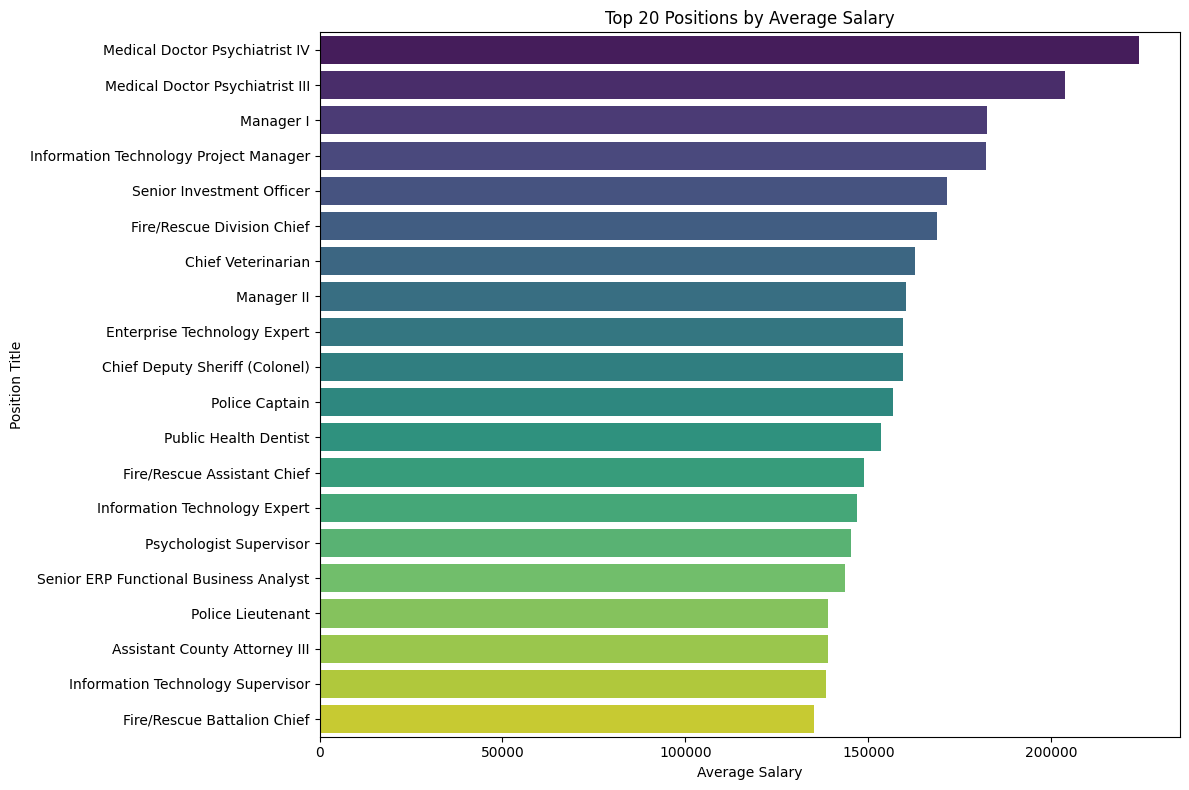

In [12]:
plt.figure(figsize=(12, 8))

top_positions = (
    df.groupby('Position Title')['Average of Base Salary']
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

sns.barplot(x=top_positions.values, y=top_positions.index, palette='viridis')

plt.title('Top 20 Positions by Average Salary')
plt.xlabel('Average Salary')
plt.ylabel('Position Title')
plt.tight_layout()
plt.show()


In [13]:
df['Average of Base Salary'].dtype

dtype('float64')

In [14]:
# Remove currency symbols, commas, and convert to float
df['Average of Base Salary'] = (
    df['Average of Base Salary']
    .replace('[\$,]', '', regex=True)   # Remove $ and ,
    .replace('', np.nan)                # Replace empty strings with NaN
    .astype(float)
)


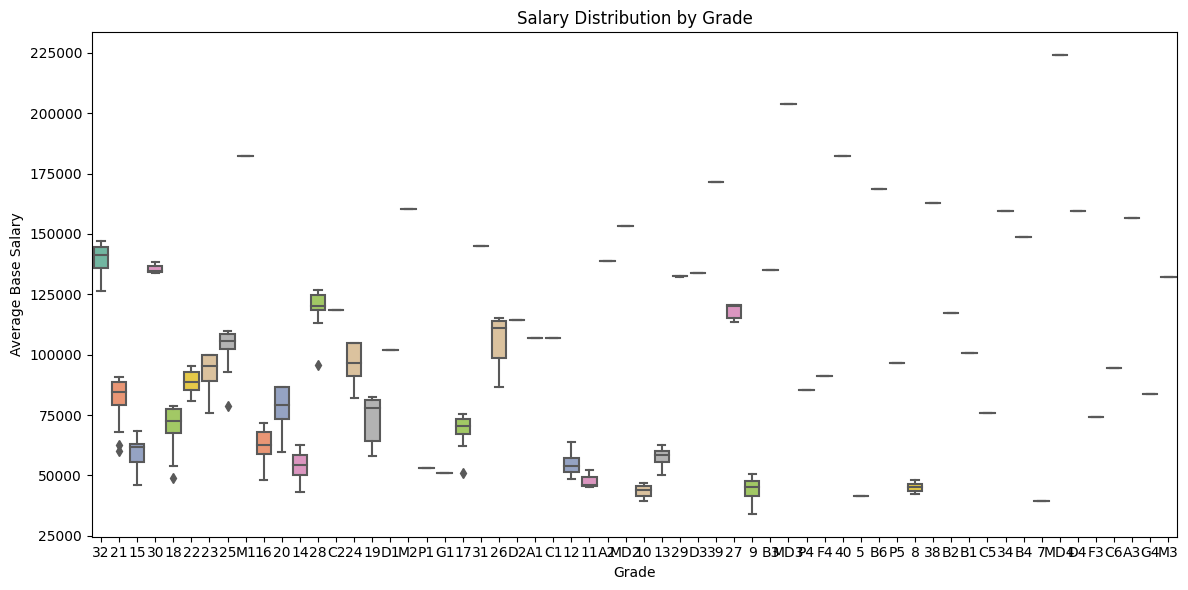

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Grade', y='Average of Base Salary', palette='Set2')

plt.title('Salary Distribution by Grade')
plt.xlabel('Grade')
plt.ylabel('Average Base Salary')
plt.tight_layout()
plt.show()

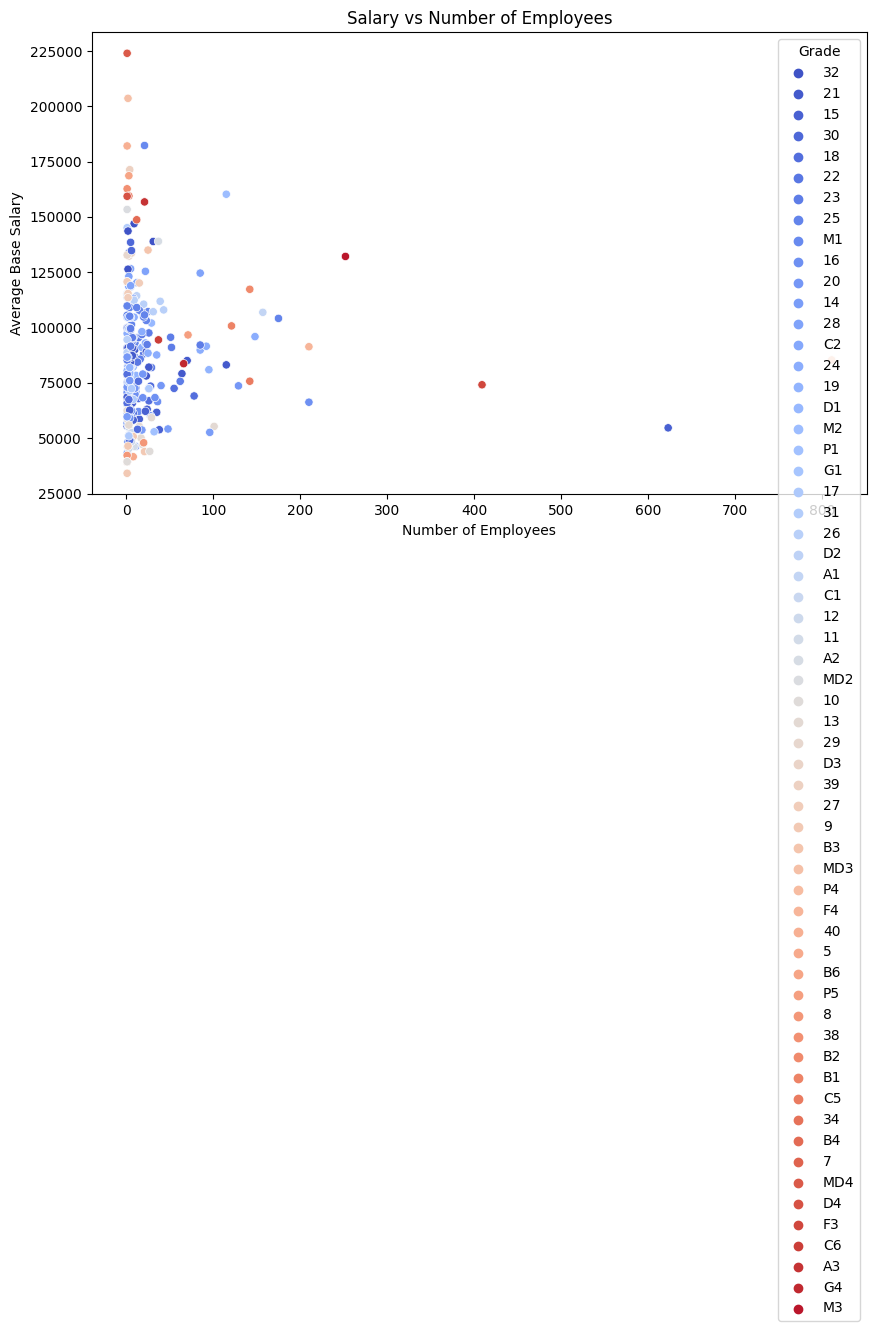

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Number of Employees', y='Average of Base Salary', hue='Grade', palette='coolwarm')

plt.title('Salary vs Number of Employees')
plt.xlabel('Number of Employees')
plt.ylabel('Average Base Salary')
plt.tight_layout()
plt.show()


In [17]:
# Remove $ and commas, then convert to float
df['Average of Base Salary'] = df['Average of Base Salary'].replace('[\$,]', '', regex=True).astype(float)


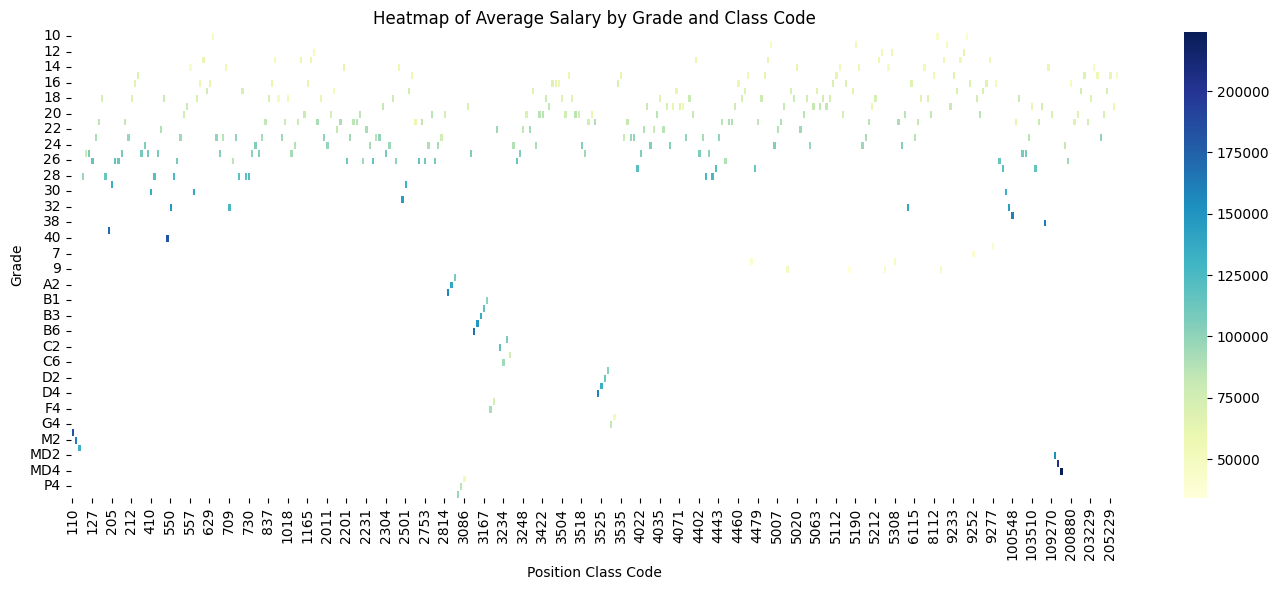

In [18]:
# Create pivot table
pivot = df.pivot_table(
    values='Average of Base Salary',
    index='Grade',
    columns='Position Class Code',
    aggfunc='mean'
)

# Plot heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='YlGnBu', annot=False, linewidths=0.5)
plt.title('Heatmap of Average Salary by Grade and Class Code')
plt.xlabel('Position Class Code')
plt.ylabel('Grade')
plt.tight_layout()
plt.show()

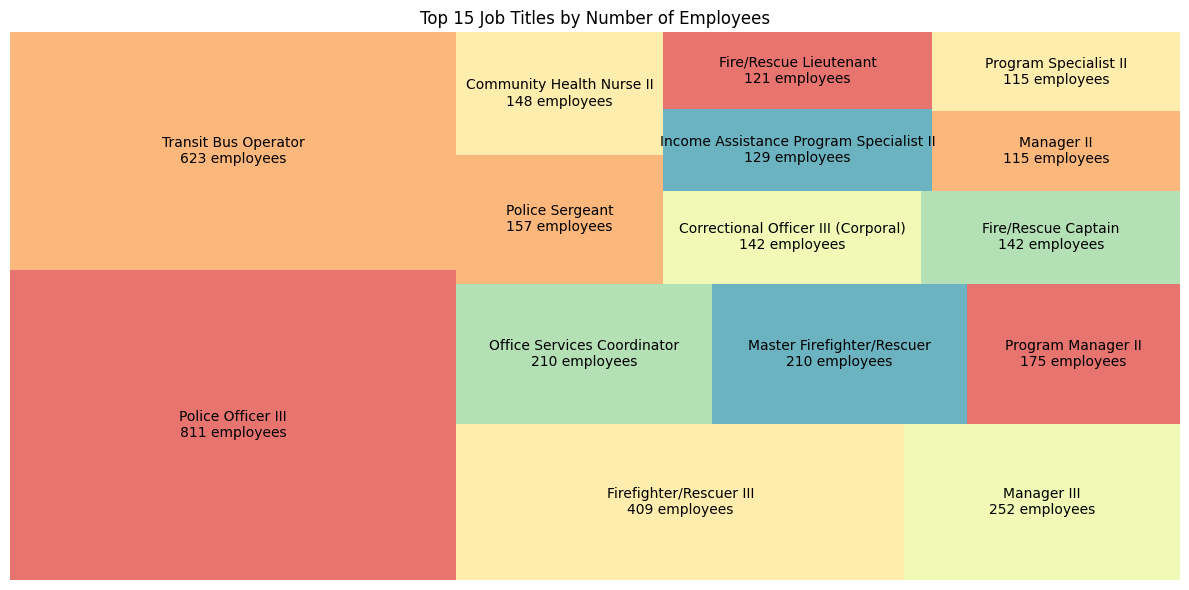

In [19]:
import squarify

top_jobs = df.groupby('Position Title').agg({'Number of Employees': 'sum'}).sort_values(by='Number of Employees', ascending=False).head(15)
sizes = top_jobs['Number of Employees']
labels = [f"{label}\n{int(val)} employees" for label, val in zip(top_jobs.index, sizes)]

plt.figure(figsize=(12, 6))
squarify.plot(sizes=sizes, label=labels, alpha=0.8, color=sns.color_palette('Spectral'))

plt.axis('off')
plt.title('Top 15 Job Titles by Number of Employees')
plt.tight_layout()
plt.show()


## Predictive modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [21]:
print(df.columns.tolist())

['Position Title', 'Position Class Code', 'Grade', 'Average of Base Salary', 'Number of Employees']


In [22]:
# Label encode categorical columns
le_position = LabelEncoder()
df['Position Title'] = le_position.fit_transform(df['Position Title'])

In [23]:
# Prepare features and target
X = df.drop('Grade', axis=1)
y = df['Grade']


In [24]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Dictionary of classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}


=== Logistic Regression ===
[[0 0 0 0 0 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 2 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 3 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 1 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 2 0 1 1 0 0 0 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 

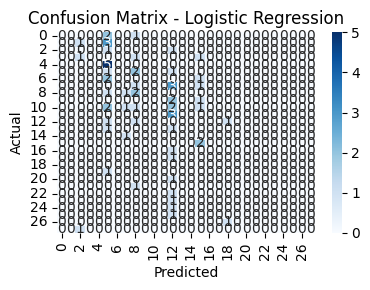

=== Random Forest ===
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
              precision    recall  f1-score   support

          11       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         0
          13       0.00      0.00      0.00         3
          14       0.25      0.25      0.25         4
          15       0.00      0.00      0.00         2
          16       0.17      0.33      0.22         3
          17       0.00      0.00      0.00         5
          18       0.09      0.25      0.13         4
          19       0.00      0.00      0.00         3
          20       0.60      0.60      0.60         5
          21       0.60      0.75      0.67         4
          22       0.25      0.33      0.29         3
          23       0.29      0.29      0.29         7
          24       0.00      0.00      0.00         3
          25       0.33      0.33      0.33    

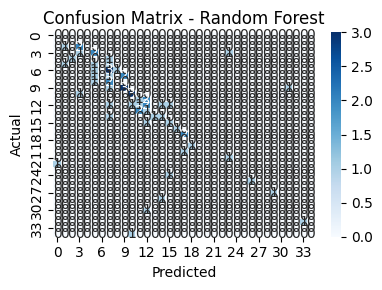

=== Decision Tree ===
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
              precision    recall  f1-score   support

          11       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         0
          13       0.00      0.00      0.00         3
          14       0.00      0.00      0.00         4
          15       0.00      0.00      0.00         2
          16       0.00      0.00      0.00         3
          17       0.00      0.00      0.00         5
          18       0.25      0.50      0.33         4
          19       0.00      0.00      0.00         3
          20       0.60      0.60      0.60         5
          21       0.25      0.25      0.25         4
          22       0.20      0.33      0.25         3
          23       0.50      0.29      0.36         7
          24       0.00      0.00      0.00         3
          25       0.33      0.33      0.33    

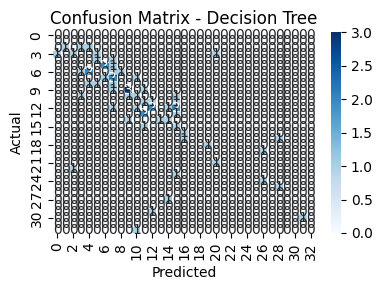

=== SVM ===
[[0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 2 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 4 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 2 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0

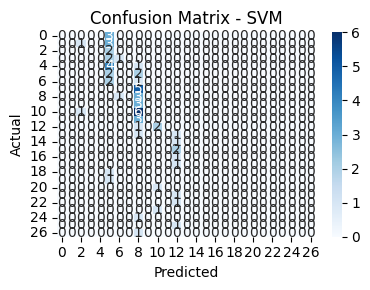

=== Naive Bayes ===
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 2 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 1 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 2 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 2 2 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 

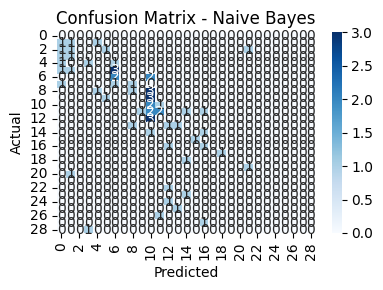

=== KNN ===
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 2 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 2 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 2 2 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 2 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 0 2 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 1 1 0 3 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 2 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0

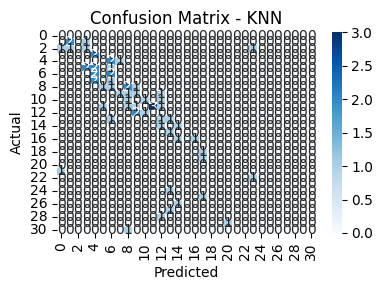

In [26]:
# Train & evaluate all models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"=== {name} ===")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()
    
    # Optional: visualize confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

## Thank you..pls upvote!!!!